# Datos geográficos de Mérida

Ejecuta las celdas desde arriba con **Run All**. Se requieren los cuatro ZIP originales en `data/raw`: Censo, Marco Geoestadístico, DENUE y ATUS.

Si falta GeoPandas, ejecuta `%pip install geopandas` en una celda y reinicia el kernel.


In [1]:
from pathlib import Path
import zipfile
import pandas as pd
from IPython.display import display

# Buscar data/raw desde notebooks/ o desde la raíz del proyecto.
# Si tu carpeta está en otro lugar, escribe su ruta en DATA_RAW.
DATA_RAW = None
if DATA_RAW is None:
    candidates = [Path.cwd() / "data" / "raw"]
    candidates += [parent / "data" / "raw" for parent in Path.cwd().parents]
    DATA_RAW = next((p for p in candidates if p.is_dir()), None)
    if DATA_RAW is None:
        raise FileNotFoundError(
            f"No se encontró data/raw desde {Path.cwd()}. "
            "Abre el notebook dentro del proyecto o configura DATA_RAW."
        )
DATA_RAW = Path(DATA_RAW).expanduser().resolve()
print("Carpeta de datos:", DATA_RAW)

def data_file(name):
    path = DATA_RAW / name
    if not path.is_file():
        raise FileNotFoundError(f"Falta el archivo: {path}")
    return path

def zip_member(archive, basename):
    with zipfile.ZipFile(archive) as z:
        matches = [name for name in z.namelist()
                   if Path(name).name.lower() == basename.lower()]
    if len(matches) != 1:
        raise ValueError(f"Se esperaba un archivo {basename} en {archive.name}; encontrados: {matches}")
    return matches[0]

def geo_layer(archive, basename):
    member = zip_member(archive, basename)
    return gpd.read_file(f"zip://{archive.as_posix()}!{member}")


Carpeta de datos: /Users/diegoloria/upy/9/bussines-intelligence/merida-urban-intelligence 2/data/raw


## Censo 2020 ageb

https://www.inegi.org.mx/programas/ccpv/2020/#datos_abiertos (Principales resultados por AGEB y manzana urbana)

In [2]:
path_censo_zip = data_file("ageb_mza_urbana_31_cpv2020_csv.zip")
with zipfile.ZipFile(path_censo_zip) as z:
    for filename in z.namelist():
        if filename.lower().endswith(".csv"):
            print(filename)


ageb_mza_urbana_31_cpv2020/conjunto_de_datos/conjunto_de_datos_ageb_urbana_31_cpv2020.csv
ageb_mza_urbana_31_cpv2020/diccionario_de_datos/diccionario_datos_ageb_urbana_31_cpv2020.csv


In [3]:
import pandas as pd
import zipfile

path_zip = path_censo_zip

with zipfile.ZipFile(path_zip, 'r') as z:
    # Busca automáticamente el archivo del conjunto de datos dentro del ZIP
    csv_target = [f for f in z.namelist() if f.endswith('.csv') and 'conjunto_de_datos' in f][0]
    
    with z.open(csv_target) as f:
        df_censo = pd.read_csv(f, encoding='utf-8-sig', low_memory=False,
                               dtype={'AGEB': 'string'})

df_censo.columns = df_censo.columns.str.strip()
df_censo["AGEB"] = df_censo["AGEB"].str.strip().str.upper().str.zfill(4)
for column in ["ENTIDAD", "MUN", "LOC", "MZA"]:
    df_censo[column] = pd.to_numeric(df_censo[column], errors="raise")
df_censo.head()

,ENTIDAD,NOM_ENT,MUN,NOM_MUN,LOC,NOM_LOC,AGEB,MZA,POBTOT,POBFEM,...,VPH_TELEF,VPH_CEL,VPH_INTER,VPH_STVP,VPH_SPMVPI,VPH_CVJ,VPH_SINRTV,VPH_SINLTC,VPH_SINCINT,VPH_SINTIC
0,31,Yucatán,0,Total de la entidad Yucatán,0,Total de la entidad,0000,0,2320898,1180619,...,176401,580440,339142,306523,129272,60161,33887,67719,283586,16519
1,31,Yucatán,1,Abalá,0,Total del municipio,0000,0,6550,3247,...,6,1383,345,542,36,15,137,436,1394,78
2,31,Yucatán,1,Abalá,1,Total de la localidad urbana,0000,0,2039,1024,...,*,516,181,323,24,8,28,92,375,14
3,31,Yucatán,1,Abalá,1,Total AGEB urbana,0107,0,843,430,...,*,204,60,104,7,4,11,43,164,7
4,31,Yucatán,1,Abalá,1,Abalá,0107,1,51,32,...,0,11,*,6,0,0,0,*,9,0


In [4]:
df_censo.columns.tolist()

['ENTIDAD',
 'NOM_ENT',
 'MUN',
 'NOM_MUN',
 'LOC',
 'NOM_LOC',
 'AGEB',
 'MZA',
 'POBTOT',
 'POBFEM',
 'POBMAS',
 'P_0A2',
 'P_0A2_F',
 'P_0A2_M',
 'P_3YMAS',
 'P_3YMAS_F',
 'P_3YMAS_M',
 'P_5YMAS',
 'P_5YMAS_F',
 'P_5YMAS_M',
 'P_12YMAS',
 'P_12YMAS_F',
 'P_12YMAS_M',
 'P_15YMAS',
 'P_15YMAS_F',
 'P_15YMAS_M',
 'P_18YMAS',
 'P_18YMAS_F',
 'P_18YMAS_M',
 'P_3A5',
 'P_3A5_F',
 'P_3A5_M',
 'P_6A11',
 'P_6A11_F',
 'P_6A11_M',
 'P_8A14',
 'P_8A14_F',
 'P_8A14_M',
 'P_12A14',
 'P_12A14_F',
 'P_12A14_M',
 'P_15A17',
 'P_15A17_F',
 'P_15A17_M',
 'P_18A24',
 'P_18A24_F',
 'P_18A24_M',
 'P_15A49_F',
 'P_60YMAS',
 'P_60YMAS_F',
 'P_60YMAS_M',
 'REL_H_M',
 'POB0_14',
 'POB15_64',
 'POB65_MAS',
 'PROM_HNV',
 'PNACENT',
 'PNACENT_F',
 'PNACENT_M',
 'PNACOE',
 'PNACOE_F',
 'PNACOE_M',
 'PRES2015',
 'PRES2015_F',
 'PRES2015_M',
 'PRESOE15',
 'PRESOE15_F',
 'PRESOE15_M',
 'P3YM_HLI',
 'P3YM_HLI_F',
 'P3YM_HLI_M',
 'P3HLINHE',
 'P3HLINHE_F',
 'P3HLINHE_M',
 'P3HLI_HE',
 'P3HLI_HE_F',
 'P3HLI_HE_M',
 '

In [5]:
[c for c in df_censo.columns if "AGEB" in c.upper()]

['AGEB']

In [6]:
[c for c in df_censo.columns if "POB" in c.upper()]

['POBTOT',
 'POBFEM',
 'POBMAS',
 'POB0_14',
 'POB15_64',
 'POB65_MAS',
 'POB_AFRO',
 'POB_AFRO_F',
 'POB_AFRO_M',
 'POBHOG']

In [7]:
# Filtrar registros de la ciudad de Mérida
censo_merida = df_censo[
    (df_censo["MUN"] == 50) &
    (df_censo["LOC"] == 1)
].copy()

print("Registros de Mérida:", len(censo_merida))

censo_merida[["MUN", "NOM_MUN", "LOC", "NOM_LOC", "AGEB", "MZA"]].head(10)

Registros de Mérida: 16219


,MUN,NOM_MUN,LOC,NOM_LOC,AGEB,MZA
9728,50,Mérida,1,Total de la localidad urbana,0000,0
9729,50,Mérida,1,Total AGEB urbana,0027,0
9730,50,Mérida,1,Mérida,0027,1
9731,50,Mérida,1,Mérida,0027,2
9732,50,Mérida,1,Mérida,0027,3
9733,50,Mérida,1,Mérida,0027,4
9734,50,Mérida,1,Mérida,0027,5
9735,50,Mérida,1,Mérida,0027,6
9736,50,Mérida,1,Mérida,0027,7
9737,50,Mérida,1,Mérida,0027,8


In [8]:
censo_ageb = censo_merida[
    (censo_merida["NOM_LOC"] == "Total AGEB urbana") &
    (censo_merida["MZA"] == 0)
].copy()

print("AGEB en Censo:", len(censo_ageb))
print("AGEB únicos:", censo_ageb["AGEB"].nunique())

censo_ageb[
    ["MUN", "NOM_MUN", "LOC", "AGEB", "POBTOT", "POB0_14", "POB15_64", "POB65_MAS", "PEA"]
].head()

AGEB en Censo: 483
AGEB únicos: 483


,MUN,NOM_MUN,LOC,AGEB,POBTOT,POB0_14,POB15_64,POB65_MAS,PEA
9729,50,Mérida,1,0027,21,*,19,*,15
9755,50,Mérida,1,0031,253,48,195,10,155
9778,50,Mérida,1,0120,1444,160,947,337,783
9814,50,Mérida,1,0154,186,48,135,3,117
9834,50,Mérida,1,0169,1580,153,979,447,768


## Marco Geoestadístico. Censo de Población y Vivienda 2020

http://inegi.org.mx/app/biblioteca/ficha.html?upc=889463807469

GeoPandas debe estar instalado en el entorno del kernel. La instalación se realiza solo si hace falta, como se indica al inicio.


In [9]:
import geopandas as gpd

print(gpd.__version__)

1.2.0


In [10]:
path_geo_zip = data_file("31_yucatan.zip")
with zipfile.ZipFile(path_geo_zip) as z:
    shapefiles = [f for f in z.namelist() if f.lower().endswith(".shp")]
for shp in shapefiles:
    print(shp)


conjunto_de_datos/31a.shp
conjunto_de_datos/31ar.shp
conjunto_de_datos/31cd.shp
conjunto_de_datos/31e.shp
conjunto_de_datos/31ent.shp
conjunto_de_datos/31fm.shp
conjunto_de_datos/31l.shp
conjunto_de_datos/31lpr.shp
conjunto_de_datos/31m.shp
conjunto_de_datos/31mun.shp
conjunto_de_datos/31pe.shp
conjunto_de_datos/31pem.shp
conjunto_de_datos/31sia.shp
conjunto_de_datos/31sil.shp
conjunto_de_datos/31sip.shp
conjunto_de_datos/31ti.shp


In [11]:
import os
import pandas as pd
import geopandas as gpd

results = []

for shp in shapefiles:

    path_mapa = f"zip://{path_geo_zip.as_posix()}!{shp}"
    gdf = gpd.read_file(path_mapa)

    results.append({
        "file": os.path.basename(shp),
        "rows": len(gdf),
        "columns": len(gdf.columns),
        "crs": str(gdf.crs),
        "geometry": gdf.geometry.geom_type.unique().tolist(),
        "valid_geometries": gdf.geometry.is_valid.sum()
    })

layers_info = pd.DataFrame(results)
layers_info

,file,rows,columns,crs,geometry,valid_geometries
0,31a.shp,1532,6,"PROJCS[""MEXICO_ITRF_2008_LCC"",GEOGCS[""ITRF2008...","[Polygon, MultiPolygon]",1532
1,31ar.shp,347,5,"PROJCS[""MEXICO_ITRF_2008_LCC"",GEOGCS[""MEXICO_I...","[Polygon, MultiPolygon]",347
2,31cd.shp,422,9,"PROJCS[""MEXICO_ITRF_2008_LCC"",GEOGCS[""ITRF2008...",[MultiPoint],422
3,31e.shp,131304,12,"PROJCS[""MEXICO_ITRF_2008_LCC"",GEOGCS[""ITRF2008...",[LineString],131304
4,31ent.shp,1,4,"PROJCS[""MEXICO_ITRF_2008_LCC"",GEOGCS[""MEXICO_I...",[MultiPolygon],1
5,31fm.shp,226469,27,EPSG:6372,[LineString],226469
6,31l.shp,655,7,"PROJCS[""MEXICO_ITRF_2008_LCC"",GEOGCS[""ITRF2008...","[Polygon, MultiPolygon]",655
7,31lpr.shp,10111,9,"PROJCS[""MEXICO_ITRF_2008_LCC"",GEOGCS[""MEXICO_I...",[Point],10111
8,31m.shp,48021,9,"PROJCS[""MEXICO_ITRF_2008_LCC"",GEOGCS[""ITRF2008...",[Polygon],48021
9,31mun.shp,106,5,"PROJCS[""MEXICO_ITRF_2008_LCC"",GEOGCS[""MEXICO_I...","[Polygon, MultiPolygon]",106


In [12]:
gdf_31ti = geo_layer(path_geo_zip, "31ti.shp")
gdf_31ti.head()


,CVEGEO,CVE_ENT,CVE_MUN,CVE_AGEB,NOMGEO,geometry
0,310599007,31,059,9007,Arrecife Alacrán,"POLYGON ((3760420.582 1224167.836, 3760701.702..."
1,310599238,31,059,9238,Arrecife Alacrán 11,"POLYGON ((3754140.084 1219696.386, 3754224.75 ..."
2,310599187,31,059,9187,Arrecife Alacrán 9,"POLYGON ((3752160.996 1220368.429, 3752023.413..."
3,310599308,31,059,9308,Arrecife Alacrán 17,"POLYGON ((3752634.558 1216007.797, 3752495.651..."
4,310599454,31,059,9454,Cayo Arenas 3,"POLYGON ((3586483.912 1162398.076, 3586517.061..."


In [13]:
gdf_31ti.columns.tolist()

['CVEGEO', 'CVE_ENT', 'CVE_MUN', 'CVE_AGEB', 'NOMGEO', 'geometry']

In [14]:
gdf_31ti.crs

<Projected CRS: PROJCS["MEXICO_ITRF_2008_LCC",GEOGCS["MEXICO_ITRF_ ...>
Name: MEXICO_ITRF_2008_LCC
Axis Info [cartesian]:
- [east]: Easting (metre)
- [north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Lambert Conic Conformal (2SP)
Datum: International Terrestrial Reference Frame 2008
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [15]:
gdf_31ti.geometry.geom_type.value_counts()

Polygon    54
Name: count, dtype: int64

In [16]:
gdf_31ti.geometry.is_valid.value_counts()

True    54
Name: count, dtype: int64

In [17]:
gdf_31m = geo_layer(path_geo_zip, "31m.shp")
gdf_31a = geo_layer(path_geo_zip, "31a.shp")

for layer in [gdf_31m, gdf_31a]:
    for column, width in {"CVE_MUN": 3, "CVE_LOC": 4, "CVE_AGEB": 4}.items():
        layer[column] = layer[column].astype("string").str.strip().str.upper().str.zfill(width)

print("31m")
print(gdf_31m.columns.tolist())
display(gdf_31m.head())
print("31a")
print(gdf_31a.columns.tolist())
display(gdf_31a.head())


31m
['CVEGEO', 'CVE_ENT', 'CVE_MUN', 'CVE_LOC', 'CVE_AGEB', 'CVE_MZA', 'AMBITO', 'TIPOMZA', 'geometry']


,CVEGEO,CVE_ENT,CVE_MUN,CVE_LOC,CVE_AGEB,CVE_MZA,AMBITO,TIPOMZA,geometry
0,3100100010126002,31,001,0001,0126,002,Urbana,Típica,"POLYGON ((3776317.318 1014695.955, 3776290.436..."
1,310010003008A010,31,001,0003,008A,010,Rural,Típica,"POLYGON ((3785255.76 1012979.803, 3785285.454 ..."
2,3100100070018018,31,001,0007,0018,018,Urbana,Típica,"POLYGON ((3785798.935 1021132.561, 3785818.269..."
3,3100100070018021,31,001,0007,0018,021,Urbana,Típica,"POLYGON ((3785159.752 1021511.817, 3785187.686..."
4,3100100010107029,31,001,0001,0107,029,Urbana,Típica,"POLYGON ((3776873.117 1014643.985, 3776879.112..."


31a
['CVEGEO', 'CVE_ENT', 'CVE_MUN', 'CVE_LOC', 'CVE_AGEB', 'geometry']


,CVEGEO,CVE_ENT,CVE_MUN,CVE_LOC,CVE_AGEB,geometry
0,3100100010130,31,001,0001,0130,"POLYGON ((3776847.045 1015576.473, 3776850.565..."
1,3100100010145,31,001,0001,0145,"POLYGON ((3776745.86 1015499.562, 3776745.439 ..."
2,3100100010164,31,001,0001,0164,"POLYGON ((3776136.004 1014614.653, 3776022.228..."
3,3100100010126,31,001,0001,0126,"POLYGON ((3776247.74 1014594.755, 3776229.182 ..."
4,3100100010107,31,001,0001,0107,"POLYGON ((3776613.825 1015270.341, 3776615.972..."


In [18]:
print("31m CRS:", gdf_31m.crs)
print("31m geometrías:", gdf_31m.geometry.geom_type.value_counts())
print("31m válidas:", gdf_31m.geometry.is_valid.value_counts())

print("\n31a CRS:", gdf_31a.crs)
print("31a geometrías:", gdf_31a.geometry.geom_type.value_counts())
print("31a válidas:", gdf_31a.geometry.is_valid.value_counts())

31m CRS: PROJCS["MEXICO_ITRF_2008_LCC",GEOGCS["ITRF2008",DATUM["International_Terrestrial_Reference_Frame_2008",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1061"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",12],PARAMETER["central_meridian",-102],PARAMETER["standard_parallel_1",17.5],PARAMETER["standard_parallel_2",29.5],PARAMETER["false_easting",2500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
31m geometrías: Polygon    48021
Name: count, dtype: int64
31m válidas: True    48021
Name: count, dtype: int64

31a CRS: PROJCS["MEXICO_ITRF_2008_LCC",GEOGCS["ITRF2008",DATUM["International_Terrestrial_Reference_Frame_2008",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1061"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Co

In [19]:
gdf_31a["CVE_MUN"].value_counts()

CVE_MUN
050    526
041     70
059     60
102     45
096     37
      ... 
051      2
021      2
088      2
065      1
061      1
Name: count, Length: 106, dtype: Int64

In [20]:
# Municipios disponibles en la capa 31a
print("Municipios:")
print(gdf_31a["CVE_MUN"].value_counts().sort_index())

# Verificar Mérida
print("\n¿Existe CVE_MUN = 050?")
print((gdf_31a["CVE_MUN"] == "050").any())

# Filtrar Mérida
ageb_merida = gdf_31a[
    gdf_31a["CVE_MUN"] == "050"
].copy()

print("\nNúmero de polígonos en Mérida:")
print(len(ageb_merida))

print("\nNúmero de AGEB diferentes:")
print(ageb_merida["CVE_AGEB"].nunique())

print("\nLocalidades dentro de Mérida:")
print(ageb_merida["CVE_LOC"].value_counts())

print("\nPrimeros registros:")
display(ageb_merida.head())

Municipios:
CVE_MUN
001    10
002     4
003    18
004     5
005     3
       ..
102    45
103     5
104     6
105     4
106     3
Name: count, Length: 106, dtype: Int64

¿Existe CVE_MUN = 050?
True

Número de polígonos en Mérida:
526

Número de AGEB diferentes:
526

Localidades dentro de Mérida:
CVE_LOC
0001    483
0084     13
0075     10
0093      8
0077      8
0111      4
Name: count, dtype: Int64

Primeros registros:


,CVEGEO,CVE_ENT,CVE_MUN,CVE_LOC,CVE_AGEB,geometry
412,3105000015329,31,050,0001,5329,"POLYGON ((3779478.623 1047307.492, 3779480.973..."
413,3105000012466,31,050,0001,2466,"POLYGON ((3777875.435 1056949.722, 3777947.632..."
414,310500001249A,31,050,0001,249A,"POLYGON ((3779713.782 1053802.753, 3779711.8 1..."
415,3105000015827,31,050,0001,5827,"POLYGON ((3772091.762 1052572.146, 3772125.684..."
416,3105000014706,31,050,0001,4706,"POLYGON ((3772829.128 1047931.32, 3772821.774 ..."


In [21]:
ageb_merida["CVE_AGEB"].nunique()

526

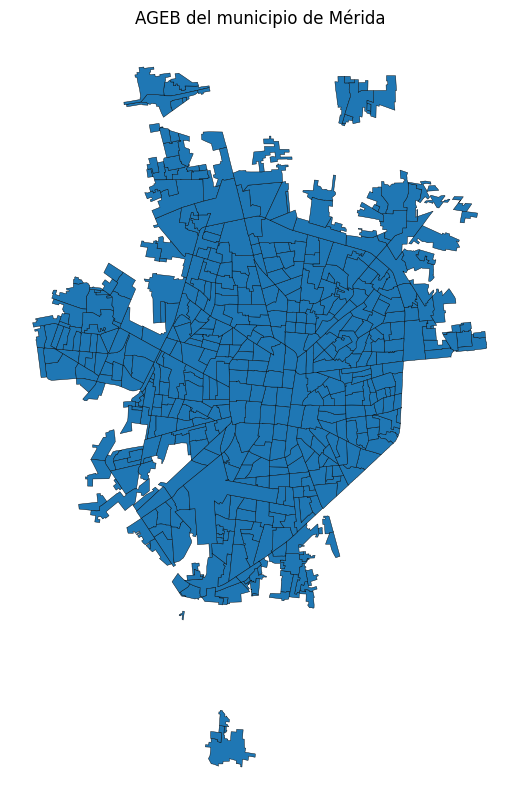

In [22]:
import matplotlib.pyplot as plt

ax = ageb_merida.plot(
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.3
)

ax.set_title("AGEB del municipio de Mérida")
ax.set_axis_off()

plt.show()

In [23]:
ageb_merida_ciudad = gdf_31a[
    (gdf_31a["CVE_MUN"] == "050") &
    (gdf_31a["CVE_LOC"] == "0001")
].copy()

print("AGEB de la ciudad de Mérida:", len(ageb_merida_ciudad))

AGEB de la ciudad de Mérida: 483


In [24]:
ageb_cartografia = set(ageb_merida_ciudad["CVE_AGEB"])
ageb_censo = set(censo_ageb["AGEB"])

print("AGEB en cartografía:", len(ageb_cartografia))
print("AGEB en Censo:", len(ageb_censo))

print("AGEB en ambos:", len(ageb_cartografia & ageb_censo))
print("AGEB solo en cartografía:", len(ageb_cartografia - ageb_censo))
print("AGEB solo en Censo:", len(ageb_censo - ageb_cartografia))

AGEB en cartografía: 483
AGEB en Censo: 483
AGEB en ambos: 483
AGEB solo en cartografía: 0
AGEB solo en Censo: 0


In [25]:
manzanas_merida = gdf_31m[
    (gdf_31m["CVE_MUN"] == "050") &
    (gdf_31m["CVE_LOC"] == "0001")
].copy()

print("Manzanas en Mérida:", len(manzanas_merida))

Manzanas en Mérida: 15728


In [26]:
manzanas_merida["AMBITO"].value_counts()

AMBITO
Urbana    15728
Name: count, dtype: int64

In [27]:
ageb_urbanas = set(ageb_merida_ciudad["CVE_AGEB"])

ageb_manzanas = set(
    manzanas_merida["CVE_AGEB"]
)

print("AGEB en la cartografía:", len(ageb_urbanas))
print("AGEB con manzanas:", len(ageb_manzanas))

print(
    "AGEB sin manzanas:",
    len(ageb_urbanas - ageb_manzanas)
)

AGEB en la cartografía: 483
AGEB con manzanas: 483
AGEB sin manzanas: 0


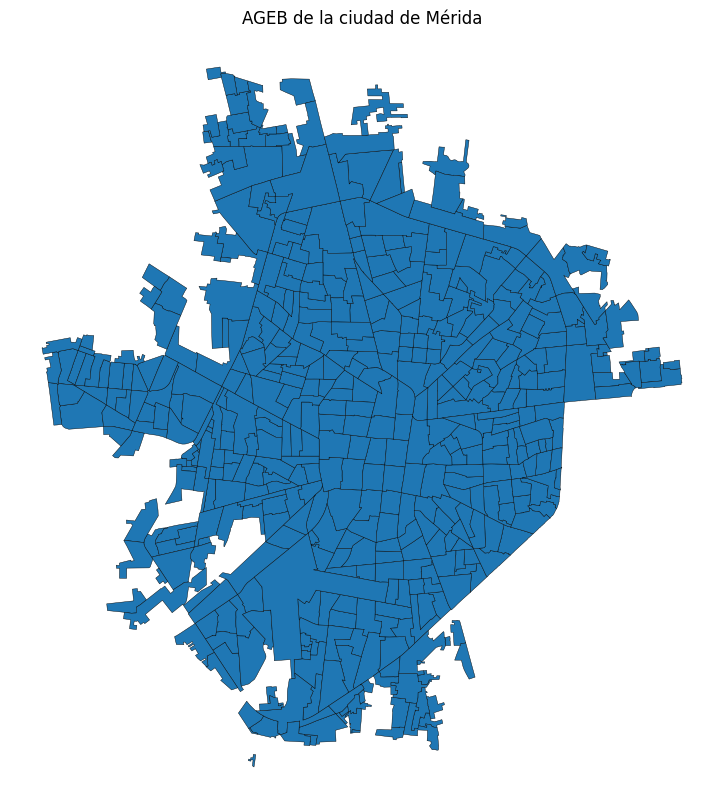

In [28]:
import matplotlib.pyplot as plt

ax = ageb_merida_ciudad.plot(
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.3
)

ax.set_title("AGEB de la ciudad de Mérida")
ax.set_axis_off()

plt.show()

In [29]:
print(ageb_merida_ciudad.crs)
print(ageb_merida_ciudad.geometry.geom_type.unique())
print(ageb_merida_ciudad.geometry.is_valid.all())
print(ageb_merida_ciudad.shape)
print(ageb_merida_ciudad["CVE_AGEB"].nunique())


PROJCS["MEXICO_ITRF_2008_LCC",GEOGCS["ITRF2008",DATUM["International_Terrestrial_Reference_Frame_2008",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1061"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",12],PARAMETER["central_meridian",-102],PARAMETER["standard_parallel_1",17.5],PARAMETER["standard_parallel_2",29.5],PARAMETER["false_easting",2500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
['Polygon']
True
(483, 6)
483


## DENUE

https://www.inegi.org.mx/app/descarga/default.html 

In [30]:
path_denue_zip = data_file("denue_31_csv.zip")
denue_csv = zip_member(path_denue_zip, "denue_inegi_31_.csv")
with zipfile.ZipFile(path_denue_zip) as z:
    print("Archivos dentro del ZIP:")
    for file in z.namelist():
        print(file)


Archivos dentro del ZIP:
diccionario_de_datos/denue_diccionario_de_datos.csv
conjunto_de_datos/denue_inegi_31_.csv
metadatos/metadatos_denue.txt


In [31]:
import pandas as pd
import zipfile

with zipfile.ZipFile(path_denue_zip) as z:
    with z.open(denue_csv) as f:
        denue_sample = pd.read_csv(f, nrows=5, encoding="latin-1")

print("Columns:", len(denue_sample.columns))
print(denue_sample.columns.tolist())

Columns: 42
['id', 'clee', 'nom_estab', 'raz_social', 'codigo_act', 'nombre_act', 'per_ocu', 'tipo_vial', 'nom_vial', 'tipo_v_e_1', 'nom_v_e_1', 'tipo_v_e_2', 'nom_v_e_2', 'tipo_v_e_3', 'nom_v_e_3', 'numero_ext', 'letra_ext', 'edificio', 'edificio_e', 'numero_int', 'letra_int', 'tipo_asent', 'nomb_asent', 'tipoCenCom', 'nom_CenCom', 'num_local', 'cod_postal', 'cve_ent', 'entidad', 'cve_mun', 'municipio', 'cve_loc', 'localidad', 'ageb', 'manzana', 'telefono', 'correoelec', 'www', 'tipoUniEco', 'latitud', 'longitud', 'fecha_alta']


In [32]:
with zipfile.ZipFile(path_denue_zip) as z:
    with z.open(denue_csv) as f:
        denue_df = pd.read_csv(
            f,
            encoding="latin-1",
            low_memory=False,
            dtype={"ageb": "string"}
        )

print("Records:", len(denue_df))
print("Columns:", len(denue_df.columns))
denue_df["ageb"] = denue_df["ageb"].str.strip().str.upper().str.zfill(4)
for column in ["cve_mun", "cve_loc"]:
    denue_df[column] = pd.to_numeric(denue_df[column], errors="raise")


Records: 146384
Columns: 42


In [33]:
print(denue_df[["cve_mun", "municipio", "cve_loc", "localidad"]].head())
print(denue_df[["cve_mun", "cve_loc"]].dtypes)

   cve_mun municipio  cve_loc  \
0       59  Progreso        3   
1       38   Hunucmá        4   
2       59  Progreso        1   
3       59  Progreso        1   
4       59  Progreso        1   

                                           localidad  
0  Chelem                                        ...  
1  Sisal                                         ...  
2  Progreso                                      ...  
3  Progreso                                      ...  
4  Progreso                                      ...  
cve_mun    int64
cve_loc    int64
dtype: object


In [34]:
denue_merida = denue_df[
    (denue_df["cve_mun"] == 50) &
    (denue_df["cve_loc"] == 1)
].copy()

print("Establishments in Merida:", len(denue_merida))
print("Unique AGEBs:", denue_merida["ageb"].nunique())

denue_merida[
    ["id", "nom_estab", "codigo_act", "nombre_act",
     "ageb", "manzana", "latitud", "longitud"]
].head()

Establishments in Merida: 55059
Unique AGEBs: 482


,id,nom_estab,codigo_act,nombre_act,ageb,manzana,latitud,longitud
79,11826222,CONTROL DE PLAGAS CORMAR,115111,Servicios de fumigación agrícola,3939,15,21.019598,-89.601481
91,10383065,COSTA FISH,114119,"Pesca y captura de peces, crustáceos, moluscos...",5225,20,20.975972,-89.615679
98,6185019,CRIADERO DE PECES Y PLANTAS ACUATICAS ENMANUEL,112519,Otra acuicultura,021A,2,20.990226,-89.627434
99,6503419,CUADRA DE CABALLOS SAN RAFAEL,115210,Servicios relacionados con la cría y explotaci...,4284,13,21.062437,-89.614360
118,6472009,GARY LEE MANTENIMIENTO AGROINDUSTRIAL,115210,Servicios relacionados con la cría y explotaci...,4871,26,21.024141,-89.665726


In [35]:
ageb_denue = set(denue_merida["ageb"].dropna())
ageb_cartography = set(ageb_merida_ciudad["CVE_AGEB"].astype("string").str.zfill(4))

print("AGEBs in cartography:", len(ageb_cartography))
print("AGEBs in DENUE:", len(ageb_denue))
print("AGEBs in both:", len(ageb_cartography & ageb_denue))
print("AGEBs only in cartography:", len(ageb_cartography - ageb_denue))
print("AGEBs only in DENUE:", len(ageb_denue - ageb_cartography))

print("\nAGEB only in cartography:")
print(ageb_cartography - ageb_denue)

AGEBs in cartography: 483
AGEBs in DENUE: 482
AGEBs in both: 473
AGEBs only in cartography: 10
AGEBs only in DENUE: 9

AGEB only in cartography:
{'6223', '6204', '6581', '4585', '4778', '0864', '6219', '5920', '676A', '6967'}


In [36]:
print("AGEBs only in DENUE:")
print(sorted(ageb_denue - ageb_cartography))

print("\nAGEBs only in cartography:")
print(sorted(ageb_cartography - ageb_denue))

AGEBs only in DENUE:
['0883', '0898', '092A', '0934', '0949', '0953', '0987', '1044', '1148']

AGEBs only in cartography:
['0864', '4585', '4778', '5920', '6204', '6219', '6223', '6581', '676A', '6967']


In [37]:
denue_missing_ageb = denue_merida[
    denue_merida["ageb"].astype("string").str.zfill(4).isin(
        ageb_denue - ageb_cartography
    )
]

denue_missing_ageb[
    [
        "ageb",
        "nom_estab",
        "nombre_act",
        "municipio",
        "localidad",
        "latitud",
        "longitud"
    ]
].head(20)

,ageb,nom_estab,nombre_act,municipio,localidad,latitud,longitud
17715,0953,PLANTA PURIFICADORA AGUA YAXJA,Purificación y embotellado de agua,Mérida,Mérida ...,20.934553,-89.709674
20024,0953,TORTILLERIA LA FLOR DEL CAMPO RA,Elaboración de tortillas de maíz y molienda de...,Mérida,Mérida ...,20.934551,-89.709800
28534,0898,ARTE Y EXPRESION,Otras industrias manufactureras,Mérida,Mérida ...,21.088278,-89.666298
29848,0934,HERRERIA SIN NOMBRE,Fabricación de productos de herrería,Mérida,Mérida ...,20.902078,-89.672848
30025,0987,KAY BUCKET,Otras industrias manufactureras,Mérida,Mérida ...,20.995699,-89.526282
31906,1148,BACHOCO,Comercio al por mayor de carne de aves,Mérida,Mérida ...,21.040523,-89.679178
36080,0987,ABARROTES HEROES,"Comercio al por menor en tiendas de abarrotes,...",Mérida,Mérida ...,20.995250,-89.528293
38897,1044,BODEGA AURRERA EXPRESS,Farmacias sin minisúper,Mérida,Mérida ...,21.016628,-89.725655
38910,0953,BODEGA AURRERA EXPRESS PASEOS DE MERIDA,Farmacias sin minisúper,Mérida,Mérida ...,20.933321,-89.710262
45260,1044,EXPENDIO DE CERVEZA CALIFORNIA,Comercio al por menor de cerveza,Mérida,Mérida ...,21.017011,-89.725478


In [38]:
print(
    denue_missing_ageb["ageb"]
    .astype("string")
    .str.zfill(4)
    .value_counts()
    .sort_index()
)

ageb
0883     7
0898     8
092A     3
0934     6
0949     4
0953    20
0987    10
1044     5
1148     1
Name: count, dtype: Int64


In [39]:
for file in sorted(DATA_RAW.rglob("*")):
    if file.is_file():
        print(file)


/Users/diegoloria/upy/9/bussines-intelligence/merida-urban-intelligence 2/data/raw/.gitkeep
/Users/diegoloria/upy/9/bussines-intelligence/merida-urban-intelligence 2/data/raw/31_yucatan.zip
/Users/diegoloria/upy/9/bussines-intelligence/merida-urban-intelligence 2/data/raw/ageb_mza_urbana_31_cpv2020_csv.zip
/Users/diegoloria/upy/9/bussines-intelligence/merida-urban-intelligence 2/data/raw/atus_2024_shp.zip
/Users/diegoloria/upy/9/bussines-intelligence/merida-urban-intelligence 2/data/raw/denue_31_csv.zip


## ATUS

http://inegi.org.mx/programas/accidentes/#datos_abiertos 

In [40]:
path_atus_zip = data_file("atus_2024_shp.zip")
with zipfile.ZipFile(path_atus_zip) as z:
    atus_shapefiles = [f for f in z.namelist() if f.lower().endswith(".shp")]
if len(atus_shapefiles) != 1:
    raise ValueError(f"Selecciona la capa ATUS correcta; capas encontradas: {atus_shapefiles}")
atus_shapefiles


['conjunto_de_datos/BASE_MUNICIPAL_ACCIDENTES_GEORREFERENCIADOS_2024.shp']

In [41]:
path_mapa = f"zip://{path_atus_zip.as_posix()}!{atus_shapefiles[0]}"
gdf = gpd.read_file(path_mapa)
for column in ["EDO", "MPIO"]:
    gdf[column] = pd.to_numeric(gdf[column], errors="raise")
if gdf.crs is None:
    raise ValueError("ATUS no tiene CRS definido. Revisa que el ZIP contenga el archivo .prj.")
gdf.head()


,ID,EDO,MES,ANIO,MPIO,HORA,MINUTOS,DIA,DIASEMANA,URBANA,...,OTROHERIDO,TOTMUERTOS,TOTHERIDOS,CLASE,CALLE1,CALLE2,CARRETERA,LONGITUD,LATITUD,geometry
0,1170966-999-0,1,1,2024,1,2,25,1,1,1,...,0,0,0,3,HEROICO COLEGIO MILITAR,ALAMEDA,None,-102.274470,21.883931,POINT (-102.27447 21.88393)
1,1170966-999-1,1,1,2024,1,3,40,1,1,1,...,0,0,0,3,AGUASCALIENTES SUR,TAMAULIPAS,None,-102.281080,21.860126,POINT (-102.28108 21.86013)
2,1170966-999-2,1,1,2024,1,4,37,1,1,1,...,0,0,1,2,CONVENCIÓN DE 1914 PONIENTE,AQUILES ELORDUY,None,-102.312406,21.880656,POINT (-102.31241 21.88066)
3,1170966-999-3,1,1,2024,1,5,0,1,1,1,...,0,0,0,3,AGUASCALIENTES SUR,KABÁH,None,-102.258142,21.859757,POINT (-102.25814 21.85976)
4,1170966-999-4,1,1,2024,1,6,45,1,1,1,...,0,0,0,3,SEGUNDO ANDADOR AGUASCALIENTES,AGUASCALIENTES ORIENTE,None,-102.252737,21.864759,POINT (-102.25274 21.86476)


In [42]:
gdf.columns.tolist()

['ID',
 'EDO',
 'MES',
 'ANIO',
 'MPIO',
 'HORA',
 'MINUTOS',
 'DIA',
 'DIASEMANA',
 'URBANA',
 'SUBURBANA',
 'TIPACCID',
 'AUTOMOVIL',
 'CAMPASAJ',
 'MICROBUS',
 'PASCAMION',
 'OMNIBUS',
 'TRANVIA',
 'CAMIONETA',
 'CAMION',
 'TRACTOR',
 'FERROCARRI',
 'MOTOCICLET',
 'BICICLETA',
 'OTROVEHIC',
 'CAUSAACCI',
 'CAPAROD',
 'SEXO',
 'ALIENTO',
 'CINTURON',
 'EDAD',
 'CONDMUERTO',
 'CONDHERIDO',
 'PASAMUERTO',
 'PASAHERIDO',
 'PEATMUERTO',
 'PEATHERIDO',
 'CICLMUERTO',
 'CICLHERIDO',
 'OTROMUERTO',
 'OTROHERIDO',
 'TOTMUERTOS',
 'TOTHERIDOS',
 'CLASE',
 'CALLE1',
 'CALLE2',
 'CARRETERA',
 'LONGITUD',
 'LATITUD',
 'geometry']

In [43]:
print(gdf.crs)
print(gdf.geometry.geom_type.unique())

EPSG:4326
['Point']


In [44]:
gdf.shape

(273822, 50)

In [45]:
# La capa ATUS ya se cargó; no es necesario leerla de nuevo.
print(f"Registros extraídos: {len(gdf)}")
print(f"Columnas: {len(gdf.columns)}")
print(f"CRS: {gdf.crs}")


Registros extraídos: 273822
Columnas: 50
CRS: EPSG:4326


In [46]:
gdf[["LATITUD", "LONGITUD", "geometry"]].head()

,LATITUD,LONGITUD,geometry
0,21.883931,-102.274470,POINT (-102.27447 21.88393)
1,21.860126,-102.281080,POINT (-102.28108 21.86013)
2,21.880656,-102.312406,POINT (-102.31241 21.88066)
3,21.859757,-102.258142,POINT (-102.25814 21.85976)
4,21.864759,-102.252737,POINT (-102.25274 21.86476)


In [47]:
gdf[["EDO", "MPIO", "TIPACCID", "ANIO", "MES", "DIA", "HORA"]].head()

,EDO,MPIO,TIPACCID,ANIO,MES,DIA,HORA
0,1,1,1,2024,1,1,2
1,1,1,4,2024,1,1,3
2,1,1,2,2024,1,1,4
3,1,1,4,2024,1,1,5
4,1,1,4,2024,1,1,6


In [48]:
print(ageb_merida.crs)
print(ageb_merida.geometry.geom_type.unique())
print(ageb_merida.geometry.is_valid.all())
print(ageb_merida.shape)
print(ageb_merida["CVE_AGEB"].nunique())

PROJCS["MEXICO_ITRF_2008_LCC",GEOGCS["ITRF2008",DATUM["International_Terrestrial_Reference_Frame_2008",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1061"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",12],PARAMETER["central_meridian",-102],PARAMETER["standard_parallel_1",17.5],PARAMETER["standard_parallel_2",29.5],PARAMETER["false_easting",2500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
['Polygon']
True
(526, 6)
526


In [49]:
atus_ageb = gdf.to_crs(ageb_merida.crs)

print(atus_ageb.crs)

PROJCS["MEXICO_ITRF_2008_LCC",GEOGCS["ITRF2008",DATUM["International_Terrestrial_Reference_Frame_2008",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1061"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",12],PARAMETER["central_meridian",-102],PARAMETER["standard_parallel_1",17.5],PARAMETER["standard_parallel_2",29.5],PARAMETER["false_easting",2500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


In [50]:
atus_ageb = gpd.sjoin(
    atus_ageb,
    ageb_merida[["CVE_AGEB", "geometry"]],
    how="left",
    predicate="within"
)

print(atus_ageb.shape)
print(atus_ageb["CVE_AGEB"].notna().sum())

(273822, 52)
2201


In [51]:
print(gdf["EDO"].value_counts().head())
print(gdf["EDO"].unique())

EDO
19    71321
26    20642
8     19503
28    11953
15    10883
Name: count, dtype: int64
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32]


In [52]:
print(gdf[["LATITUD", "LONGITUD"]].describe())

             LATITUD       LONGITUD
count  273822.000000  273822.000000
mean       23.935315    -102.077111
std         4.039172       5.405564
min        14.715060    -117.121458
25%        20.094755    -104.277039
50%        25.540150    -100.382159
75%        25.790214     -99.628631
max        32.671573     -86.746331


In [53]:
atus_yucatan = gdf[gdf["EDO"] == 31]

print(atus_yucatan["MPIO"].value_counts().sort_index())

MPIO
41     1092
50     2271
101     312
Name: count, dtype: int64


In [54]:
atus_yucatan[["EDO", "MPIO"]].drop_duplicates().sort_values("MPIO")

,EDO,MPIO
269087,31,41
270179,31,50
272450,31,101


In [55]:
atus_merida = gdf[
    (gdf["EDO"] == 31) &
    (gdf["MPIO"] == 50)
].copy()

print("Accidentes en Mérida:", len(atus_merida))

Accidentes en Mérida: 2271


In [56]:
atus_merida = atus_merida.to_crs(ageb_merida.crs)

atus_merida_ageb = gpd.sjoin(
    atus_merida,
    ageb_merida[["CVE_AGEB", "geometry"]],
    how="left",
    predicate="within"
)

print("Accidentes:", len(atus_merida_ageb))
print("Accidentes asignados a AGEB:", atus_merida_ageb["CVE_AGEB"].notna().sum())

Accidentes: 2271
Accidentes asignados a AGEB: 2180


In [57]:
print("Total de accidentes:", len(atus_merida_ageb))
print("Asignados a AGEB:", atus_merida_ageb["CVE_AGEB"].notna().sum())
print("Sin AGEB:", atus_merida_ageb["CVE_AGEB"].isna().sum())
print(
    "Porcentaje asignado:",
    round(atus_merida_ageb["CVE_AGEB"].notna().mean() * 100, 2),
    "%"
)

Total de accidentes: 2271
Asignados a AGEB: 2180
Sin AGEB: 91
Porcentaje asignado: 95.99 %
